# Dimensionality Reduction and Ordination

After preprocessing and CLR transformation, the dataset remains high-dimensional. To extract meaningful biological signals from sparse, compositional microbiome data, we employ non-linear dimensionality reduction.

### Methodological Rationale

*   **Why we bypass PCA:** Conventional PCA is explicitly discouraged for microbiome data because it assumes linear relationships and emphasizes false correlations. As [Armstrong et al. (2022)](../Papers/PCA_tsne/GeorgeAmstrong2022.pdf), *Discussion* point out, it fails to capture complex, non-linear patterns. While our CLR transformation solves the compositionality issue, forcing the high-dimensional data through a linear PCA risks stripping away critical non-linear signals before they can be visualized [Xu et al., 2020, *Introduction*](../Papers/PCA_tsne/XueliXu2020.pdf).

*   **Direct Non-Linear Embedding (t-SNE & UMAP) with Aitchison Distance**: To perfectly preserve the local structure of our data, we skip the PCA step entirely. Following the methodology of [Xu et al., 2020](../Papers/PCA_tsne/XueliXu2020.pdf), we compute the Aitchison distance (mathematically equivalent to the Euclidean distance on CLR-transformed data) across all features and feed it directly into the t-SNE and UMAP algorithms. Non-linear methods like t-SNE and UMAP are uniquely capable of revealing biological fine-scale clusters hidden from linear methods [Armstrong et al. (2022)](../Papers/PCA_tsne/GeorgeAmstrong2022.pdf). As [Xu et al., 2020](../Papers/PCA_tsne/XueliXu2020.pdf) demonstrated, bypassing linear pre-filters and applying the Aitchison distance directly to both algorithms ensures they accurately handle the compositionality of the data, leading to superior representations.

### From Geography to Global Signatures

Plotting individual countries often creates visual noise. To make the ordination interpretable, we aggregate the samples into broader socio-ecological groupings:
*   **Continents:** To identify large-scale biogeographical patterns.
*   **Lifestyle Clusters (Western vs. Non-Western):** To evaluate how industrialization and diet shape the microbial fingerprint.

### Implementation

1.  Compute the high-dimensional **Aitchison distance** directly from all CLR-transformed features (bypassing PCA).
2.  Execute **t-SNE** on this complete distance matrix to visualize non-linear structures in 2D.
3.  Evaluate the resulting clusters based on Geography and Lifestyle categories.

In [ ]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import umap
from sklearn.manifold import TSNE

In [18]:
# Load the CLR-transformed dataset
file_path = '../data/processed/06_clr_healthy_data.csv'
df = pd.read_csv(file_path)

# Feature selection and label extraction
features = [col for col in df.columns if col.startswith('msp')]
X = df[features]
labels = df['Geography']

In [ ]:
# Step 1: Principal Component Analysis (PCA)
# Acts as the foundation and noise filter for t-SNE and UMAP
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X)

# Consolidate results into a single plotting DataFrame
df_plot = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_plot['Geography'] = labels.values

# Step 2: t-SNE (Neighborhood focused)
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_pca)
df_plot['tsne_1'], df_plot['tsne_2'] = X_tsne[:, 0], X_tsne[:, 1]

# Step 3: UMAP (Global & Local structure balanced)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_pca)
df_plot['umap_1'], df_plot['umap_2'] = X_umap[:, 0], X_umap[:, 1] # type: ignore

/Users/dario/ZHAW/4.Semester/PA1_repo/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [32]:
# Consolidate results into a single plotting DataFrame
df_plot = pd.DataFrame(X, columns=[f'PC{i+1}' for i in range(X.shape[1])])
df_plot['Geography'] = labels.values

# Step 2: t-SNE (Neighborhood focused)
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
X_tsne = tsne.fit_transform(X)
df_plot['tsne_1'], df_plot['tsne_2'] = X_tsne[:, 0], X_tsne[:, 1]

# Step 3: UMAP (Global & Local structure balanced)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_pca)
df_plot['umap_1'], df_plot['umap_2'] = X_umap[:, 0], X_umap[:, 1] # type: ignore

/Users/dario/ZHAW/4.Semester/PA1_repo/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


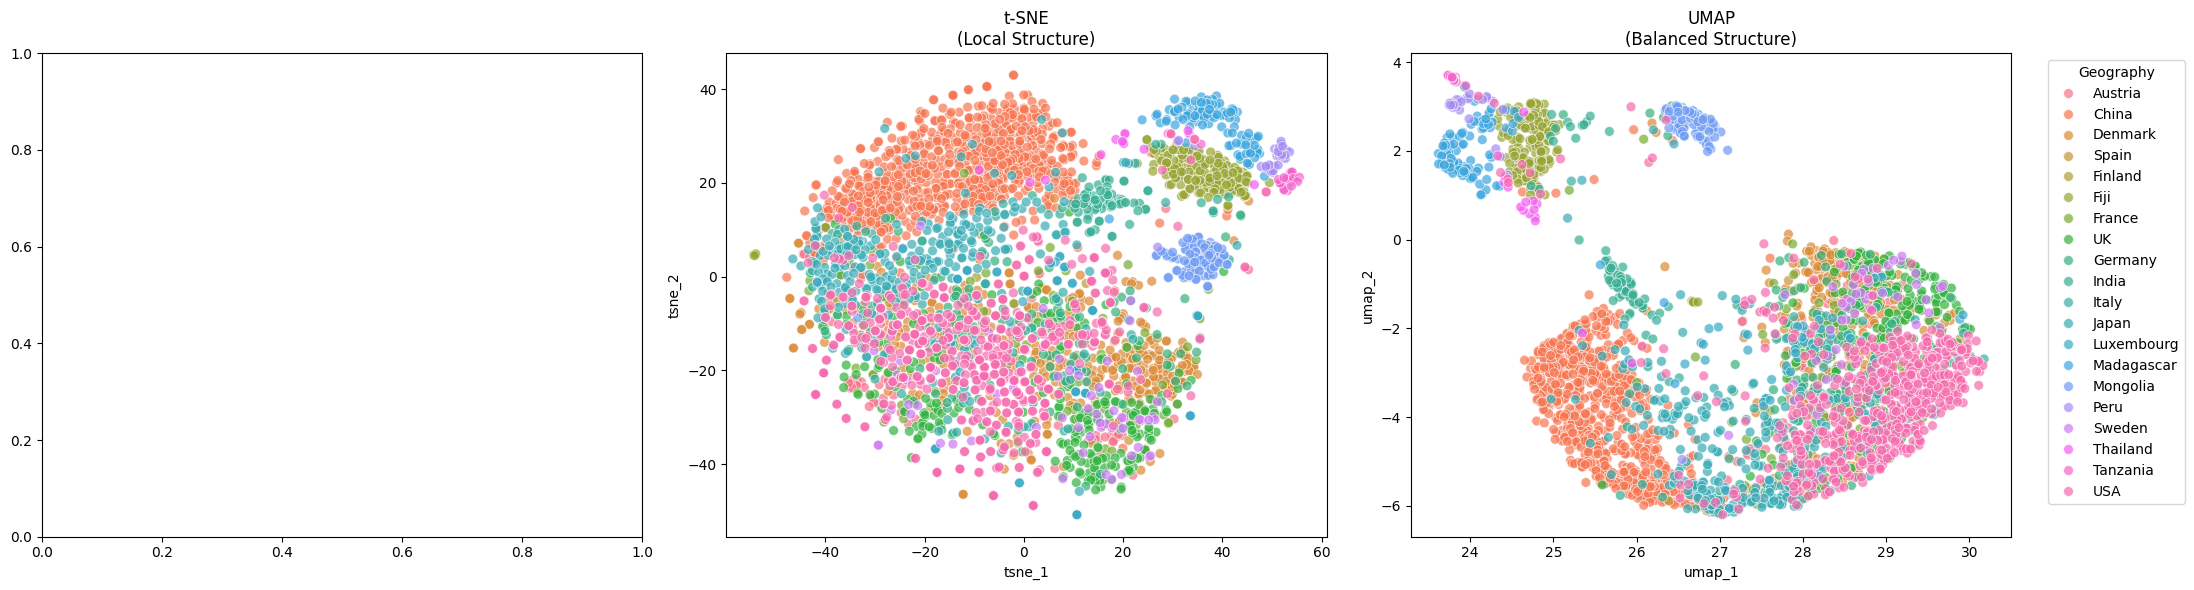

Workflow complete. Dimensionality reduced from 596 MSPs to 434 Principal Components.


In [34]:
# Visualization: Side-by-side Comparison
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot t-SNE
sns.scatterplot(data=df_plot, x='tsne_1', y='tsne_2', hue='Geography', ax=axes[1], palette='husl', s=50, alpha=0.7)
axes[1].set_title('t-SNE\n(Local Structure)')
axes[1].get_legend().remove()

# Plot UMAP
sns.scatterplot(data=df_plot, x='umap_1', y='umap_2', hue='Geography', ax=axes[2], palette='husl', s=50, alpha=0.7)
axes[2].set_title('UMAP\n(Balanced Structure)')
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Geography')

plt.tight_layout()
plt.show()

print(f"Workflow complete. Dimensionality reduced from {len(features)} MSPs to {X_pca.shape[1]} Principal Components.")

AttributeError: 'NoneType' object has no attribute 'remove'

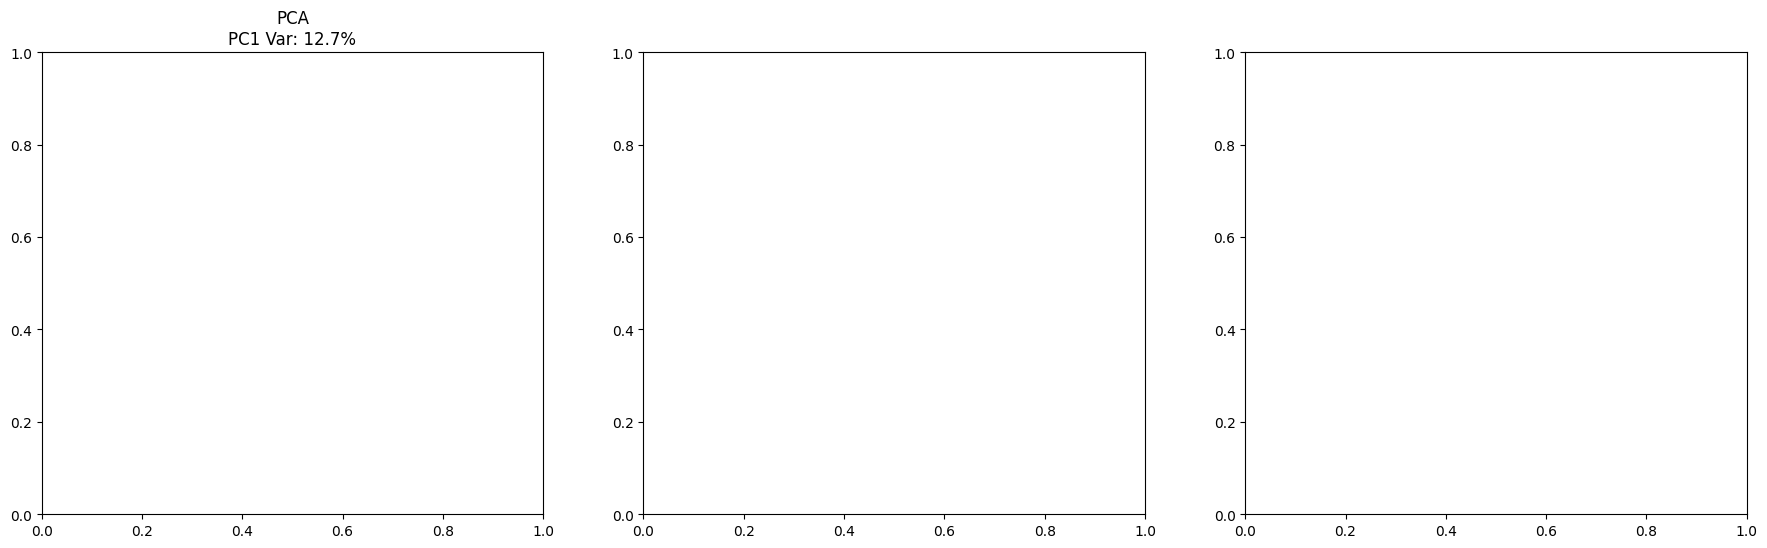

In [33]:
# Visualization: Side-by-side Comparison
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot PCA
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Geography', ax=axes[0], palette='husl', s=50, alpha=0.6)
axes[0].set_title(f'PCA\nPC1 Var: {pca.explained_variance_ratio_[0]:.1%}')
axes[0].get_legend().remove()

# Plot t-SNE
sns.scatterplot(data=df_plot, x='tsne_1', y='tsne_2', hue='Geography', ax=axes[1], palette='husl', s=50, alpha=0.7)
axes[1].set_title('t-SNE\n(Local Structure)')
axes[1].get_legend().remove()

# Plot UMAP
sns.scatterplot(data=df_plot, x='umap_1', y='umap_2', hue='Geography', ax=axes[2], palette='husl', s=50, alpha=0.7)
axes[2].set_title('UMAP\n(Balanced Structure)')
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Geography')

plt.tight_layout()
plt.show()

print(f"Workflow complete. Dimensionality reduced from {len(features)} MSPs to {X_pca.shape[1]} Principal Components.")

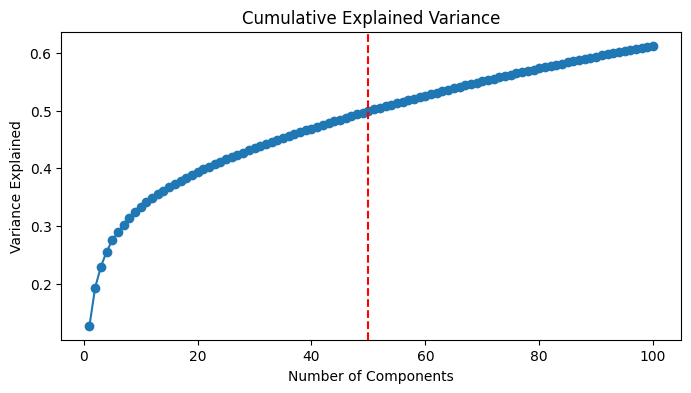

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), 'o-')
plt.axvline(50, color='red', linestyle='--')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Variance Explained")
plt.show()

/Users/dario/ZHAW/4.Semester/PA1_repo/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


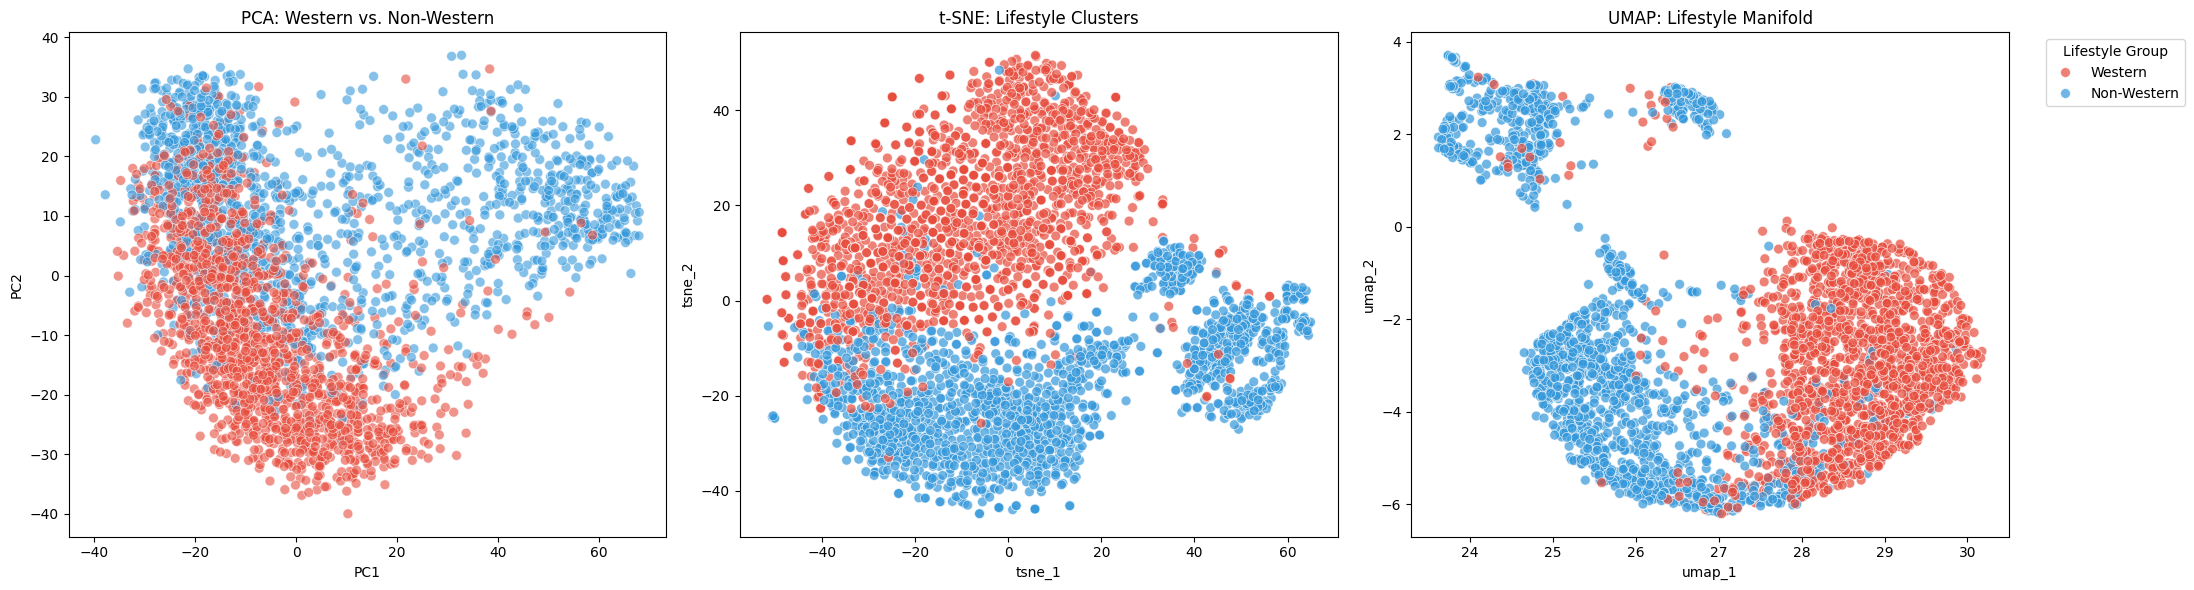

Plotting complete. Color-coded by Lifestyle (Western n=1573, Non-Western n=1555)


In [31]:
# Lifestyle Mapping (Western vs. Non-Western)
lifestyle_map = {
    'Austria': 'Western', 'Denmark': 'Western', 'Spain': 'Western', 
    'Finland': 'Western', 'France': 'Western', 'UK': 'Western', 
    'Germany': 'Western', 'Italy': 'Western', 'Luxembourg': 'Western', 'Sweden': 'Western',
    'USA': 'Western',
    'China': 'Non-Western', 'India': 'Non-Western', 'Japan': 'Non-Western', 
    'Mongolia': 'Non-Western', 'Thailand': 'Non-Western',
    'Peru': 'Non-Western', 'Madagascar': 'Non-Western', 
    'Tanzania': 'Non-Western', 'Fiji': 'Non-Western'
}

# Neue Spalte für die Gruppierung erstellen
df['Lifestyle'] = df['Geography'].map(lifestyle_map)

# Feature Auswahl
features = [col for col in df.columns if col.startswith('msp')]
X = df[features]
labels_lifestyle = df['Lifestyle']

# Step 1: PCA (Wir nutzen 50 oder 100 PCs für die beste Balance aus Signal und Rauschen)
pca = PCA(n_components=0.95, random_state=42) 
X_pca = pca.fit_transform(X)

# DataFrame für die Plots vorbereiten
df_plot = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_plot['Lifestyle'] = labels_lifestyle.values

# Step 2: t-SNE
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_pca)
df_plot['tsne_1'], df_plot['tsne_2'] = X_tsne[:, 0], X_tsne[:, 1]

# Step 3: UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_pca)
df_plot['umap_1'], df_plot['umap_2'] = X_umap[:, 0], X_umap[:, 1]

# --- VISUALISIERUNG ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Palette festlegen für harten Kontrast (z.B. Blau für Non-Western, Rot für Western)
my_palette = {'Western': '#e74c3c', 'Non-Western': '#3498db'}

# PCA Plot
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Lifestyle', ax=axes[0], palette=my_palette, s=50, alpha=0.6)
axes[0].set_title('PCA: Western vs. Non-Western')
axes[0].get_legend().remove()

# t-SNE Plot
sns.scatterplot(data=df_plot, x='tsne_1', y='tsne_2', hue='Lifestyle', ax=axes[1], palette=my_palette, s=50, alpha=0.7)
axes[1].set_title('t-SNE: Lifestyle Clusters')
axes[1].get_legend().remove()

# UMAP Plot
sns.scatterplot(data=df_plot, x='umap_1', y='umap_2', hue='Lifestyle', ax=axes[2], palette=my_palette, s=50, alpha=0.7)
axes[2].set_title('UMAP: Lifestyle Manifold')
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Lifestyle Group')

plt.tight_layout()
plt.show()

print(f"Plotting complete. Color-coded by Lifestyle (Western n={sum(df['Lifestyle']=='Western')}, Non-Western n={sum(df['Lifestyle']=='Non-Western')})")